# EddyPro biomet file (2004-2025)

**notebook version**: `1` (27 Jul 2026)

## ℹ️ About this notebook

Writes the **biomet file that EddyPro reads during flux computation**. It takes the finished meteo
products, converts their timestamp to the convention EddyPro expects, renames the six variables to
EddyPro's names and units, and writes one CSV.

Nothing is computed or corrected here. Every value is exactly what `30_PRODUCTS` exported; the only
changes are the timestamp convention, the column names and units, and gaps written as `-9999`.

**Output:**

- `EDDYPRO_BIOMET_CH-LAE_2004-2025.csv` — six variables on a continuous 30MIN end-of-period
  timestamp, in EddyPro's biomet layout (two header lines: names, then units).

This is the only notebook of the `40_EXPORTS` substage. The substage holds re-formats of finished
products for a downstream consumer, which is why it sits after `30_PRODUCTS` rather than inside it.

It replaces the retired `x-99_FormatMeteoForEddyProFluxProcessing.ipynb`, which wrote
`CH-LAE_2004-2024_meteo_aux.csv` from the earlier merged file. Two differences: the source is now
`30_PRODUCTS/99_METEO_MERGED_2004-2025.parquet`, and the exported timestamps are end-of-period —
the earlier file was written on middle-of-period timestamps. See the timestamp section below.

Format reference:
[EddyPro help: Supported biomet file formats](https://www.licor.com/support/EddyPro/topics/biomet-data-format.html)

***

## 📇 Data sources

One input: the merged meteo product `30_PRODUCTS/99_METEO_MERGED_2004-2025.parquet`. Reading the
merged file rather than the eight per-variable files means this export cannot disagree with the
products, and it inherits the merged file's continuous 30MIN index.

| EddyPro column | unit (EddyPro notation) | source column | product notebook |
|---|---|---|---|
| `Ta_1_1_1` | `C` | `TA_T1_47_1_gfXG` | `30_PRODUCTS/02` (gap-filled) |
| `Rg_1_1_1` | `W+1m-2` | `SW_IN_T1_47_1_gfXG` | `30_PRODUCTS/01` (gap-filled) |
| `RH_1_1_1` | `%` | `RH_T1_47_1` | `30_PRODUCTS/04` (reconstructed) |
| `Lwin_1_1_1` | `W+1m-2` | `LW_IN_T1_47_1` | `30_PRODUCTS/06` (measured) |
| `Pa_1_1_1` | `kPa` | `PA_T1_47_1` | `30_PRODUCTS/05` (measured) |
| `PPFD_1_1_1` | `umol+1m-2s-1` | `PPFD_IN_T1_47_1_gfXG` | `30_PRODUCTS/03` (gap-filled) |

The other columns of the merged product (`VPD`, `PREC`, `SWC`, `TS`) are not part of the EddyPro
biomet input and are not exported here.

## 🔀 Gap-filled or measured

For each variable this notebook takes **the most complete version the products offer**: the
gap-filled column where one exists (`SW_IN`, `TA`, `PPFD_IN`), the reconstructed one for `RH`, and
the measured series with its gaps for `PA` and `LW_IN`, which have no filled version.

The reason is that a gap in the biomet file does not reach EddyPro as a gap. Biomet values enter
the flux computation itself — air density and the WPL terms, spectral corrections, the analyser
surface-heating term — and where a value is missing EddyPro substitutes a fallback derived from the
raw data or from the values in the metadata file. A missing record therefore does not remove a
correction, it silently changes how that correction was obtained, and the change is not visible in
the flux output. A modelled value from the site's own gap-filling is closer to the measurement than
that fallback and keeps one method across the whole record.

The cost is that the biomet format carries **no provenance column**: the file cannot say which
values are modelled. That information stays in the products, whose flag columns are summarised in
the next section and remain the reference for anyone asking how a given half-hour was produced. Any
analysis of the resulting fluxes that depends on a biomet variable being measured has to consult
the product, not this file.

`PA` and `LW_IN` keep their gaps, which are written as `-9999`: both start in September 2005, so
the first 20 months of the record have no value at all, and neither is reconstructed by its
product notebook.

## 🕐 Timestamp convention

**The products are on `TIMESTAMP_MID`; EddyPro's biomet file needs end-of-period timestamps.** The
conversion happens in this notebook, explicitly, before the formatting class is called.

`FormatMeteoForEddyProFluxProcessing` does **not** convert. Its internal
`TimestampSanitizer(output_middle_timestamp=False)` means "do not convert to middle" — whatever
convention the index carries is split into the two timestamp columns and written out unchanged. A
frame handed to it on `TIMESTAMP_MID` produces a file on `TIMESTAMP_MID`, without warning.

That is what happened in the retired predecessor notebook: `CH-LAE_2004-2024_meteo_aux.csv` carries
middle-of-period timestamps, its first record reading `2004-09-20, 10:45`. Measured against the
convention EddyPro expects, that file is shifted 15 minutes early throughout. The file written here
replaces it.

Two consequences of the end-of-period convention, both expected:

- The first record is labelled `2004-01-01 00:30` (the period 00:00-00:30), not `00:00`.
- The last record is labelled `2026-01-01 00:00` — the end of the last 30-minute period of 2025.
  The file still covers 2004-2025; the year in its name is the last year of **data**, not the last
  label in the timestamp column.

## ⚙️ Settings

In [1]:
from pathlib import Path

# Source: the merged meteo product in the external (untracked) data folder, written by 30_PRODUCTS/99.
PRODDIR = Path(r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
               r"\workflow\10_METEO\30_PRODUCTS")
SOURCEFILE = PRODDIR / "99_METEO_MERGED_2004-2025.parquet"

# Output: the data-side folder mirroring this notebook's own folder.
OUTDIR = Path(r"F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data"
              r"\workflow\10_METEO\40_EXPORTS")
OUTNAME = "EDDYPRO_BIOMET_CH-LAE_2004-2025"

REQUIRED_TIME_RESOLUTION = '30min'
MISSING_VALUE = -9999  # EddyPro's missing-value code

# Columns of the merged product that are exported.
SW_IN = 'SW_IN_T1_47_1_gfXG'
TA = 'TA_T1_47_1_gfXG'
PPFD_IN = 'PPFD_IN_T1_47_1_gfXG'
RH = 'RH_T1_47_1'
PA = 'PA_T1_47_1'
LW_IN = 'LW_IN_T1_47_1'

# EddyPro name and unit for each source column. The unit strings are EddyPro's own notation and are
# written as the second header line of the biomet file. Insertion order is the column order of the
# exported file.
RENAME = {
    TA: ('Ta_1_1_1', 'C'),
    SW_IN: ('Rg_1_1_1', 'W+1m-2'),
    RH: ('RH_1_1_1', '%'),
    LW_IN: ('Lwin_1_1_1', 'W+1m-2'),
    PA: ('Pa_1_1_1', 'kPa'),
    PPFD_IN: ('PPFD_1_1_1', 'umol+1m-2s-1'),
}

# Provenance flag of each exported column in the merged product, or None where the product carries
# none. Not exported (the biomet format has no place for it), only reported below.
PROVENANCE = {
    TA: 'FLAG_TA_T1_47_1_ISFILLED',
    SW_IN: 'FLAG_SW_IN_T1_47_1_ISFILLED',
    RH: 'FLAG_RH_T1_47_1_MISSING',
    LW_IN: None,
    PA: None,
    PPFD_IN: 'FLAG_PPFD_IN_T1_47_1_ISFILLED',
}

### Imports

In [2]:
from datetime import datetime

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd

import diive as dv
from diive.core.times.times import TimestampSanitizer, insert_timestamp
from diive.io.formats.meteo import FormatMeteoForEddyProFluxProcessing

import warnings

warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 1000)

# Start time is kept so the last cell can report the total runtime of the notebook.
NOTEBOOK_START = datetime.now()
print(f"Last run: {NOTEBOOK_START.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"diive v{dv.__version__ if hasattr(dv, '__version__') else '?'}, pandas v{pd.__version__}")

Last run: 2026-07-27 14:39:35
diive v0.91.0, pandas v3.0.3


## ⬇️ Load the merged meteo product

In [3]:
merged = pd.read_parquet(SOURCEFILE)

# The merged product is stored on TIMESTAMP_MID. The conversion below depends on that being true,
# and insert_timestamp() reads the convention from the index name, so this is asserted, not assumed.
assert merged.index.name == 'TIMESTAMP_MIDDLE', f"unexpected index name: {merged.index.name}"

_wanted = list(RENAME) + [f for f in PROVENANCE.values() if f]
_missing = [c for c in _wanted if c not in merged.columns]
assert not _missing, f"not in the merged product: {_missing}"

df = merged[list(RENAME)].copy()
print(f"{SOURCEFILE.name}: {len(merged):,} rows, {merged.shape[1]} columns")
print(f"Exported subset: {df.shape[1]} columns, {df.index[0]} -> {df.index[-1]} ({df.index.name})")
df.head()

99_METEO_MERGED_2004-2025.parquet: 385,728 rows, 30 columns
Exported subset: 6 columns, 2004-01-01 00:15:00 -> 2025-12-31 23:45:00 (TIMESTAMP_MIDDLE)


,TA_T1_47_1_gfXG,SW_IN_T1_47_1_gfXG,RH_T1_47_1,LW_IN_T1_47_1,PA_T1_47_1,PPFD_IN_T1_47_1_gfXG
TIMESTAMP_MIDDLE,,,,,,
2004-01-01 00:15:00,6.938439,0.0,97.718962,NaN,NaN,0.0
2004-01-01 00:45:00,6.938439,0.0,96.918962,NaN,NaN,0.0
2004-01-01 01:15:00,8.341139,0.0,93.552296,NaN,NaN,0.0
2004-01-01 01:45:00,8.341139,0.0,92.652296,NaN,NaN,0.0
2004-01-01 02:15:00,8.205807,0.0,93.985629,NaN,NaN,0.0


### Provenance of the exported columns

How each column was produced, from the flag columns of the merged product. This table is the only
place the information appears: the biomet file itself cannot carry it. The meaning of each flag
code is documented in the product notebook that wrote it (`30_PRODUCTS/01`-`06`); code `0` is the
measured record in all of them.

In [4]:
rows = []
for _col in RENAME:
    _s = merged[_col]
    _flagcol = PROVENANCE[_col]
    _row = {"EddyPro": RENAME[_col][0], "source column": _col,
            "first value": _s.first_valid_index().date() if _s.first_valid_index() is not None else None,
            "gaps (-9999)": int(_s.isna().sum()),
            "gaps %": round(_s.isna().mean() * 100, 2)}
    if _flagcol:
        _vc = merged[_flagcol].value_counts(normalize=True).mul(100).round(1).sort_index()
        _row["measured (flag 0) %"] = _vc.get(0, 0.0)
        _row["flags (% by code)"] = {int(k): v for k, v in _vc.items()}
    else:
        _row["measured (flag 0) %"] = "no flag, as measured"
        _row["flags (% by code)"] = "no flag"
    rows.append(_row)
pd.DataFrame(rows).set_index("EddyPro")

,source column,first value,gaps (-9999),gaps %,measured (flag 0) %,flags (% by code)
EddyPro,,,,,,
Ta_1_1_1,TA_T1_47_1_gfXG,2004-01-01,0,0.00,95.7,"{0: 95.7, 1: 3.9, 2: 0.4, 4: 0.0}"
Rg_1_1_1,SW_IN_T1_47_1_gfXG,2004-01-01,0,0.00,91.2,"{0: 91.2, 1: 4.5, 2: 0.2, 3: 4.1}"
RH_1_1_1,RH_T1_47_1,2004-01-01,0,0.00,95.7,"{0: 95.7, 3: 4.1, 4: 0.2}"
Lwin_1_1_1,LW_IN_T1_47_1,2005-09-14,34759,9.01,"no flag, as measured",no flag
Pa_1_1_1,PA_T1_47_1,2005-09-02,33290,8.63,"no flag, as measured",no flag
PPFD_1_1_1,PPFD_IN_T1_47_1_gfXG,2004-01-01,0,0.00,95.7,"{0: 95.7, 1: 2.2, 2: 0.2, 3: 2.0, 4: 0.0}"


## 🕐 Convert to end-of-period timestamps

`TimestampSanitizer` first, because it validates the 30MIN resolution and sets the index frequency
that the shift is derived from — a parquet read back from disk carries no `freq`, and without it
the half-interval shift cannot be computed. `output_middle_timestamp=False` keeps the index as it
is; it does not convert to end.

`insert_timestamp(convention='end')` then does the conversion, reading the current convention from
the index name (`TIMESTAMP_MIDDLE`) and adding half an interval. It prints a frequency-mismatch
note when it re-sanitizes the new index (`<30 * Minutes>` against `30min`); the two are the same
resolution written differently.

In [5]:
_first_mid, _last_mid, _n = df.index[0], df.index[-1], len(df)

df = TimestampSanitizer(data=df, output_middle_timestamp=False,
                        nominal_freq=REQUIRED_TIME_RESOLUTION, verbose=True).get()
df = insert_timestamp(data=df, convention='end', set_as_index=True, verbose=True)

# The shift must be exactly half an averaging interval, and must not gain or lose records.
assert df.index.name == 'TIMESTAMP_END'
assert df.index[0] == _first_mid + pd.Timedelta('15min'), df.index[0]
assert df.index[-1] == _last_mid + pd.Timedelta('15min'), df.index[-1]
assert len(df) == _n, f"{_n:,} -> {len(df):,} records"
assert df.index.is_monotonic_increasing and not df.index.has_duplicates

print(f"\nMID {_first_mid} -> {_last_mid}")
print(f"END {df.index[0]} -> {df.index[-1]}   ({len(df):,} records, unchanged)")

────────────────────────────────────── Timestamp sanitization ──────────────────────────────────────

> Validate naming (TIMESTAMP_MIDDLE): OK

> Convert to datetime: OK

> Remove NaT values: none

> Sort ascending: OK

...

> Validate monotonicity: OK

> Detect frequency: 30min (all methods agree)

> Regularize gaps: OK

> Adding new timestamp column TIMESTAMP_END to show end of averaging period ...


MID 2004-01-01 00:15:00 -> 2025-12-31 23:45:00
END 2004-01-01 00:30:00 -> 2026-01-01 00:00:00   (385,728 records, unchanged)


### Negative control

`insert_timestamp()` decides the shift from the **name** of the index. An index that does not
declare its convention leaves the shift undefined, and the failure mode to rule out is that it
passes the data through unshifted — which would look exactly like a successful run and write a file
15 minutes off, as the predecessor notebook did.

In [6]:
_bad = df.head(48).copy()
_bad.index.name = 'timestamp'  # no longer states the convention
try:
    insert_timestamp(data=_bad, convention='end', set_as_index=True)
except ValueError as e:
    print(f"OK, raises on an unnamed timestamp index:\n  {e}")
else:
    raise AssertionError("insert_timestamp() accepted an index that does not state its convention")

# And converting an already-END index to 'end' must be a no-op rather than a second shift.
_again = insert_timestamp(data=df.head(48).copy(), convention='end', set_as_index=True)
assert _again.index.equals(df.head(48).index), "converting END -> END moved the timestamps"
print("OK, END -> END leaves the index unchanged.")

OK, raises on an unnamed timestamp index:
  Invalid timestamp index name: 'timestamp'. Expected one of ['TIMESTAMP_END', 'TIMESTAMP_START', 'TIMESTAMP_MIDDLE']. The index name indicates whether the timestamp represents the END, START, or MIDDLE of the averaging period. Rename your index before calling this function.
OK, END -> END leaves the index unchanged.


## 🧮 Format for EddyPro

`FormatMeteoForEddyProFluxProcessing` splits the index into the two header-line columns
`TIMESTAMP_1` (date) and `TIMESTAMP_2` (time), fills every gap with `-9999`, and renames the
columns to a two-level header of name and unit.

In [7]:
f = FormatMeteoForEddyProFluxProcessing(df=df, cols=RENAME)
f.run()
res = f.get_results()
res

────────────────────────────────────── Timestamp sanitization ──────────────────────────────────────

> Validate naming (TIMESTAMP_END): OK

> Convert to datetime: OK

> Remove NaT values: none

> Sort ascending: OK

...

> Regularize gaps: OK

> Splitting timestamp into two separate columns ('TIMESTAMP_1', 'yyyy-mm-dd') and ('TIMESTAMP_2', 
'HH:MM')

> Filling missing values with -9999 ...

> Renaming columns ...

,TIMESTAMP_1,TIMESTAMP_2,Ta_1_1_1,Rg_1_1_1,RH_1_1_1,Lwin_1_1_1,Pa_1_1_1,PPFD_1_1_1
,yyyy-mm-dd,HH:MM,C,W+1m-2,%,W+1m-2,kPa,umol+1m-2s-1
TIMESTAMP_END,,,,,,,,
2004-01-01 00:30:00,2004-01-01,00:30,6.938439,0.0,97.718962,-9999.000000,-9999.000000,0.0
2004-01-01 01:00:00,2004-01-01,01:00,6.938439,0.0,96.918962,-9999.000000,-9999.000000,0.0
2004-01-01 01:30:00,2004-01-01,01:30,8.341139,0.0,93.552296,-9999.000000,-9999.000000,0.0
2004-01-01 02:00:00,2004-01-01,02:00,8.341139,0.0,92.652296,-9999.000000,-9999.000000,0.0
2004-01-01 02:30:00,2004-01-01,02:30,8.205807,0.0,93.985629,-9999.000000,-9999.000000,0.0
...,...,...,...,...,...,...,...,...
2025-12-31 22:00:00,2025-12-31,22:00,-3.081644,0.0,42.332976,210.420480,93.435334,0.0
2025-12-31 22:30:00,2025-12-31,22:30,-3.084372,0.0,39.230344,210.648200,93.422110,0.0


### Checks

In [8]:
# Column set and order, exactly as EddyPro will read them.
_expected = [('TIMESTAMP_1', 'yyyy-mm-dd'), ('TIMESTAMP_2', 'HH:MM')] + [RENAME[c] for c in df.columns]
assert list(res.columns) == _expected, list(res.columns)
assert len(res) == len(df), f"{len(df):,} -> {len(res):,} records"
assert not res.isna().any().any(), "NaN left in the output; every gap must be -9999"

# The two timestamp columns must reproduce the end-of-period index they were split from.
_split = pd.to_datetime(res[('TIMESTAMP_1', 'yyyy-mm-dd')] + ' ' + res[('TIMESTAMP_2', 'HH:MM')])
assert (_split.values == res.index.values).all(), "the split timestamp columns do not match the index"

# Every -9999 must stand for a gap that was already there, and every gap must have become -9999.
for _src, _new in RENAME.items():
    _nan = int(df[_src].isna().sum())
    _fill = int((res[_new] == MISSING_VALUE).sum())
    assert _nan == _fill, f"{_src}: {_nan:,} NaN but {_fill:,} times {MISSING_VALUE}"
    print(f"  {_new[0]:<12} {_src:<24} {_fill:>7,} x {MISSING_VALUE} ({_fill / len(res) * 100:>5.2f} %)")
print(f"\n{len(res):,} records, {len(res.columns)} columns, {res.index[0]} -> {res.index[-1]}")

  Ta_1_1_1     TA_T1_47_1_gfXG                0 x -9999 ( 0.00 %)
  Rg_1_1_1     SW_IN_T1_47_1_gfXG             0 x -9999 ( 0.00 %)
  RH_1_1_1     RH_T1_47_1                     0 x -9999 ( 0.00 %)
  Lwin_1_1_1   LW_IN_T1_47_1             34,759 x -9999 ( 9.01 %)
  Pa_1_1_1     PA_T1_47_1                33,290 x -9999 ( 8.63 %)
  PPFD_1_1_1   PPFD_IN_T1_47_1_gfXG           0 x -9999 ( 0.00 %)

385,728 records, 8 columns, 2004-01-01 00:30:00 -> 2026-01-01 00:00:00


## 📊 Overview figures

One fingerprint per exported variable, drawn from the formatted frame with `-9999` set back to
`NaN`, so what is plotted is what the file contains. Gaps show as blank; a timestamp error would
show as a tilted or displaced diurnal pattern.

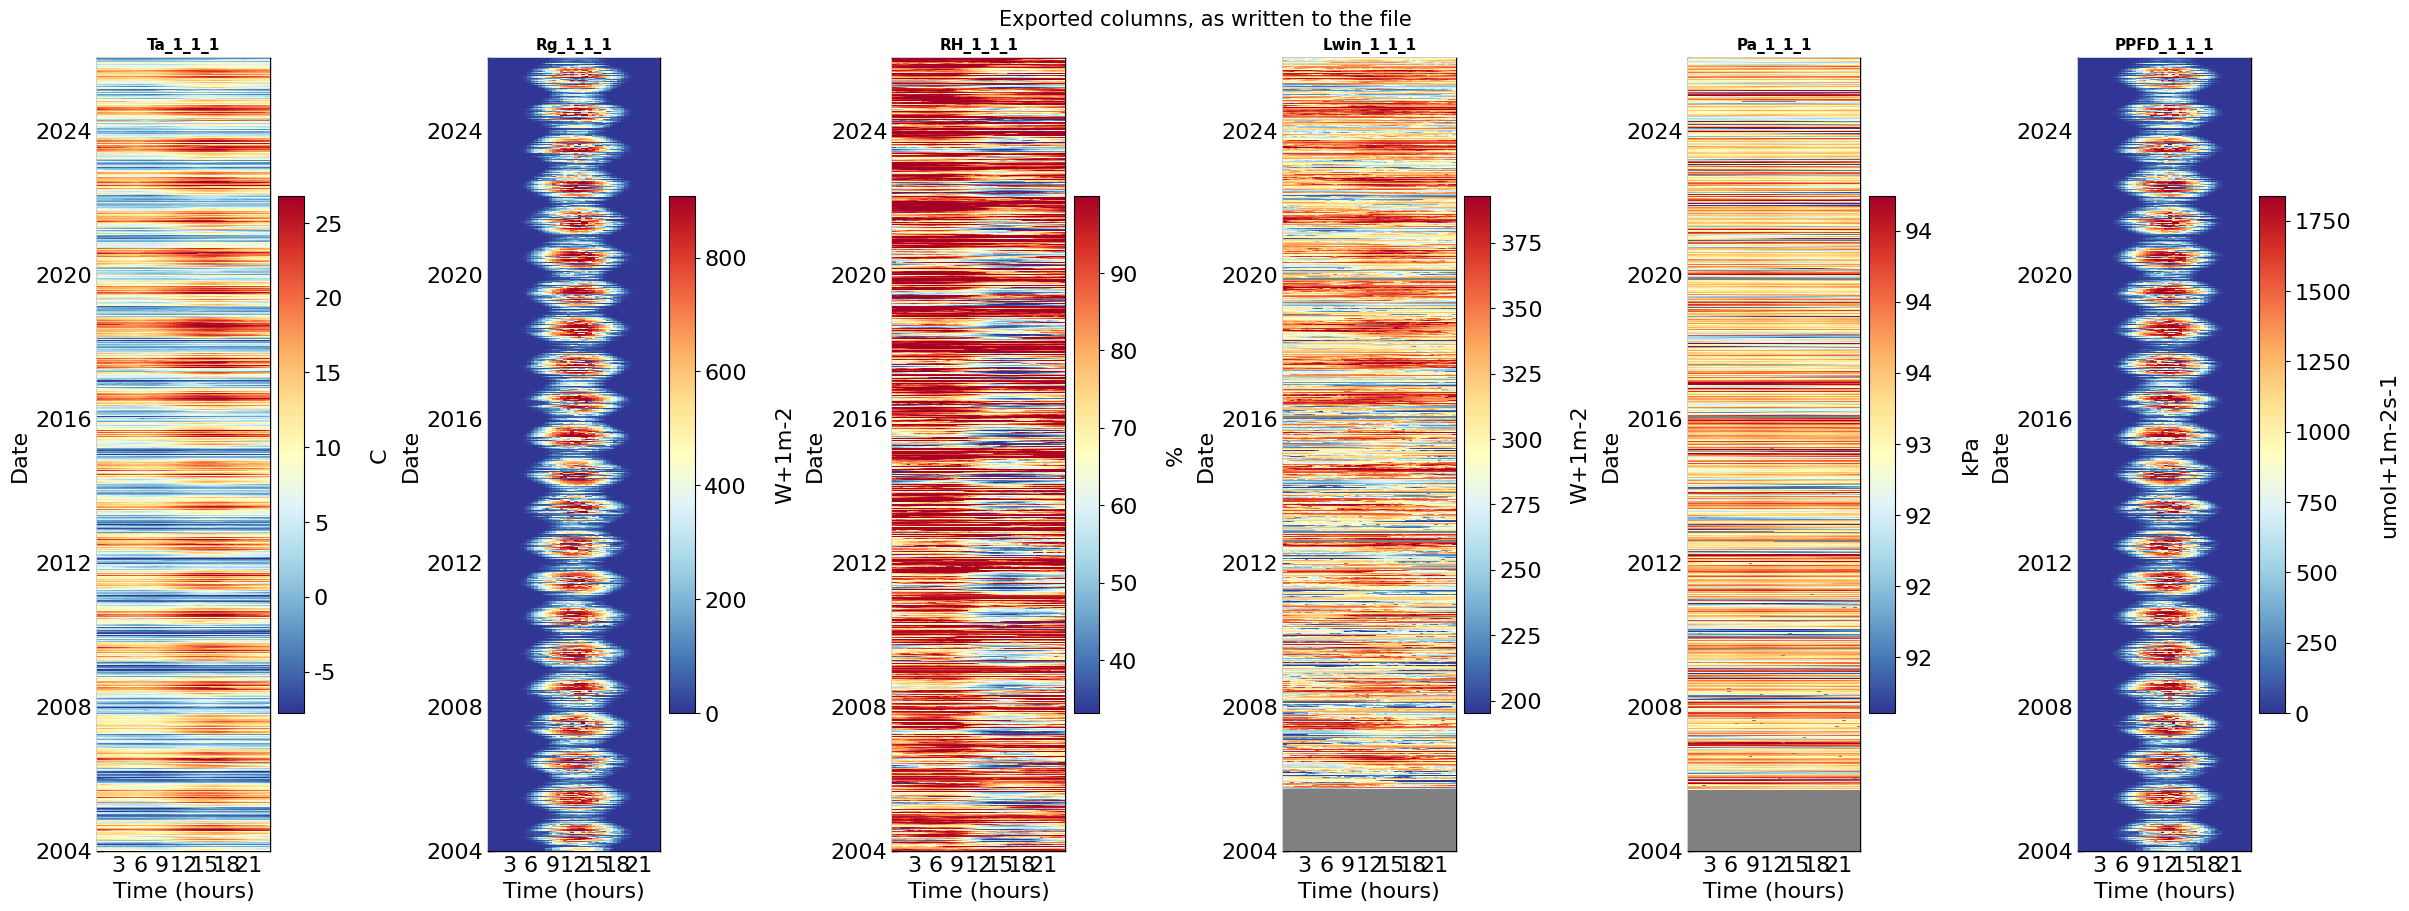

In [9]:
_plotcols = [c for c in res.columns if not str(c[0]).startswith('TIMESTAMP')]
fig, axs = plt.subplots(ncols=len(_plotcols), figsize=(4 * len(_plotcols), 9), dpi=100,
                        layout="constrained")
fig.suptitle("Exported columns, as written to the file", fontsize=15)
for _ax, _col in zip(axs, _plotcols):
    _series = res[_col].replace(to_replace=MISSING_VALUE, value=np.nan)
    _series.name = _col[0]  # the column label is a (name, unit) tuple, the plot wants a name
    dv.plotting.HeatmapDateTime(series=_series).plot(
        ax=_ax, cb_digits_after_comma=0, zlabel=_col[1],
        vmin=_series.quantile(.01), vmax=_series.quantile(.99),
        format_style=dv.plotting.FormatStyle(title=_col[0], title_fontsize=11))

## 💾 Export

In [10]:
OUTDIR.mkdir(parents=True, exist_ok=True)
outpath = OUTDIR / f"{OUTNAME}.csv"
res.to_csv(outpath, index=False)  # the timestamp lives in the two columns, not in the index
print(f"Wrote {outpath}")
print(f"      {outpath.stat().st_size / 1024 ** 2:.1f} MB")

Wrote F:\Sync\luhk_work\dev-data\datasets-data\dataset_ch-lae_flux_product-data\workflow\10_METEO\40_EXPORTS\EDDYPRO_BIOMET_CH-LAE_2004-2025.csv
      39.7 MB


### Read the written file back

Checked against the file on disk rather than against the frame in memory, since the file is what
EddyPro reads.

In [11]:
with open(outpath) as fh:
    for _ in range(3):
        print(fh.readline().rstrip())

back = pd.read_csv(outpath, header=[0, 1])
assert back.shape == res.shape, f"{res.shape} written, {back.shape} read back"
assert list(back.columns) == list(res.columns), "header lines differ"
_numeric = [c for c in res.columns if not str(c[0]).startswith('TIMESTAMP')]
assert np.allclose(back[_numeric].to_numpy(dtype=float), res[_numeric].to_numpy(dtype=float))
assert (back[('TIMESTAMP_1', 'yyyy-mm-dd')] == res[('TIMESTAMP_1', 'yyyy-mm-dd')].values).all()
assert (back[('TIMESTAMP_2', 'HH:MM')] == res[('TIMESTAMP_2', 'HH:MM')].values).all()
print(f"\nRead back: {len(back):,} rows x {back.shape[1]} columns, matches what was written.")

TIMESTAMP_1,TIMESTAMP_2,Ta_1_1_1,Rg_1_1_1,RH_1_1_1,Lwin_1_1_1,Pa_1_1_1,PPFD_1_1_1
yyyy-mm-dd,HH:MM,C,W+1m-2,%,W+1m-2,kPa,umol+1m-2s-1
2004-01-01,00:30,6.93843936920166,0.0,97.71896236557714,-9999.0,-9999.0,0.0

Read back: 385,728 rows x 8 columns, matches what was written.


## 📝 Notes for use

- **Timestamps are end-of-period.** The first record is labelled `2004-01-01 00:30` and the last
  `2026-01-01 00:00`; the file covers 2004-2025.
- **`-9999` is the missing value**, and it occurs in `Pa_1_1_1` and `Lwin_1_1_1` only. Both start
  in September 2005 and keep the gaps of their products; the other four columns are complete.
- **The file carries no provenance.** `Ta_1_1_1`, `Rg_1_1_1` and `PPFD_1_1_1` are gap-filled and
  `RH_1_1_1` is reconstructed, in the proportions reported above. Which half-hour was measured is
  recorded only in the flag columns of the products in `30_PRODUCTS`.
- **Re-run this notebook after any product it reads is re-exported**, and after `30_PRODUCTS/99` is
  re-run. It has no state of its own: the file is a view of the merged product at the time it was
  written.

***

In [12]:
_runtime = datetime.now() - NOTEBOOK_START
print(f"Finished: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')} (runtime {_runtime})")

Finished: 2026-07-27 14:39:50 (runtime 0:00:14.158776)
